## DATA MINING (DS 312)

# Maternal Health Risk Data Set

غاده المعاوي

ماريا الحجي

 طيف الفيفي

 حنان القحطاني

غيداء الحربي

### description

This dataset was collected from hospitals and community clinics using an IoT-based maternal health monitoring system. It aims to assess the health risk level of pregnant women based on vital signs.

Size: Contains over 1,000 records with 7 columns.

### Features:



- Age : Age of the pregnant woman in years.
- SystolicBP : The upper value of Systolic blood pressure in mmHg.
- DiastolicBP : The lower value of Diastolic blood pressure in mmHg.
- BS : Blood glucose level in mmol/L.
- BodyTemp : Body temperature in Fahrenheit.
- HeartRate: Heart rate in beats per minute.

### Target Variable:
RiskLevel : Predicted health risk level during pregnancy. It is a categorical variable with three classes:
- low risk: Low risk
- mid risk: Medium risk
- high risk: High risk

The data for this project was taken from [Click here](https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data/data)
.


In [ ]:
!pip install -U scikit-learn
!pip install -U imbalanced-learn
!pip install pydotplus
!pip install --upgrade tensorflow --user

In [ ]:
#Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder, label_binarize
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, jaccard_score, recall_score, f1_score, roc_auc_score, log_loss
from sklearn.metrics import roc_curve, auc
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn import tree
import pydotplus
from io import StringIO
import matplotlib.image as mpimg

## Proper	Loading	of	the	dataset

In [ ]:
df=pd.read_csv("Maternal Health Risk Data Set.csv",sep=';')

## Exploratory	Data	Analysis	(EDA)

In [ ]:
df

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk
...,...,...,...,...,...,...,...
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk


In [ ]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


In [ ]:
df.tail()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   object 
dtypes: float64(2), int64(4), object(1)
memory usage: 55.6+ KB


In [ ]:
df.describe()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,29.871795,113.198225,76.460552,8.725986,98.665089,74.301775
std,13.474386,18.403913,13.885796,3.293532,1.371384,8.088702
min,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000
25%,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000
50%,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000
75%,39.000000,120.000000,90.000000,8.000000,98.000000,80.000000
max,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000


In [ ]:
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [ ]:
df.shape

(1014, 7)

## Data	Preprocessing

In [ ]:
print(df.isnull().any())

Age            False
SystolicBP     False
DiastolicBP    False
BS             False
BodyTemp       False
HeartRate      False
RiskLevel      False
dtype: bool


In [ ]:
# Number of missing values in every column
print(df.isnull().sum())
# From the code above we know that there are no missing values but if we had any we would be using this code :
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)
print(df)

     Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0     25         130           80  15.0      98.0         86  high risk
1     35         140           90  13.0      98.0         70  high risk
2     29          90           70   8.0     100.0         80  high risk
3     30         140           85   7.0      98.0         70  high risk
4     35         120           60   6.1      98.0         76   low risk
..   ...         ...          ...   ...       ...        ...        ...
673   12         100           50   6.4      98.0         70   mid risk
674   15         100           60   6.0      98.0         80   low risk
703   15         100           49   7.6      98.0         77   low risk
704   12         100           50   6.0      98.0         70   mid risk
705   21         100           50   6.8      98.0         60   low risk

[452 rows x 7 columns]


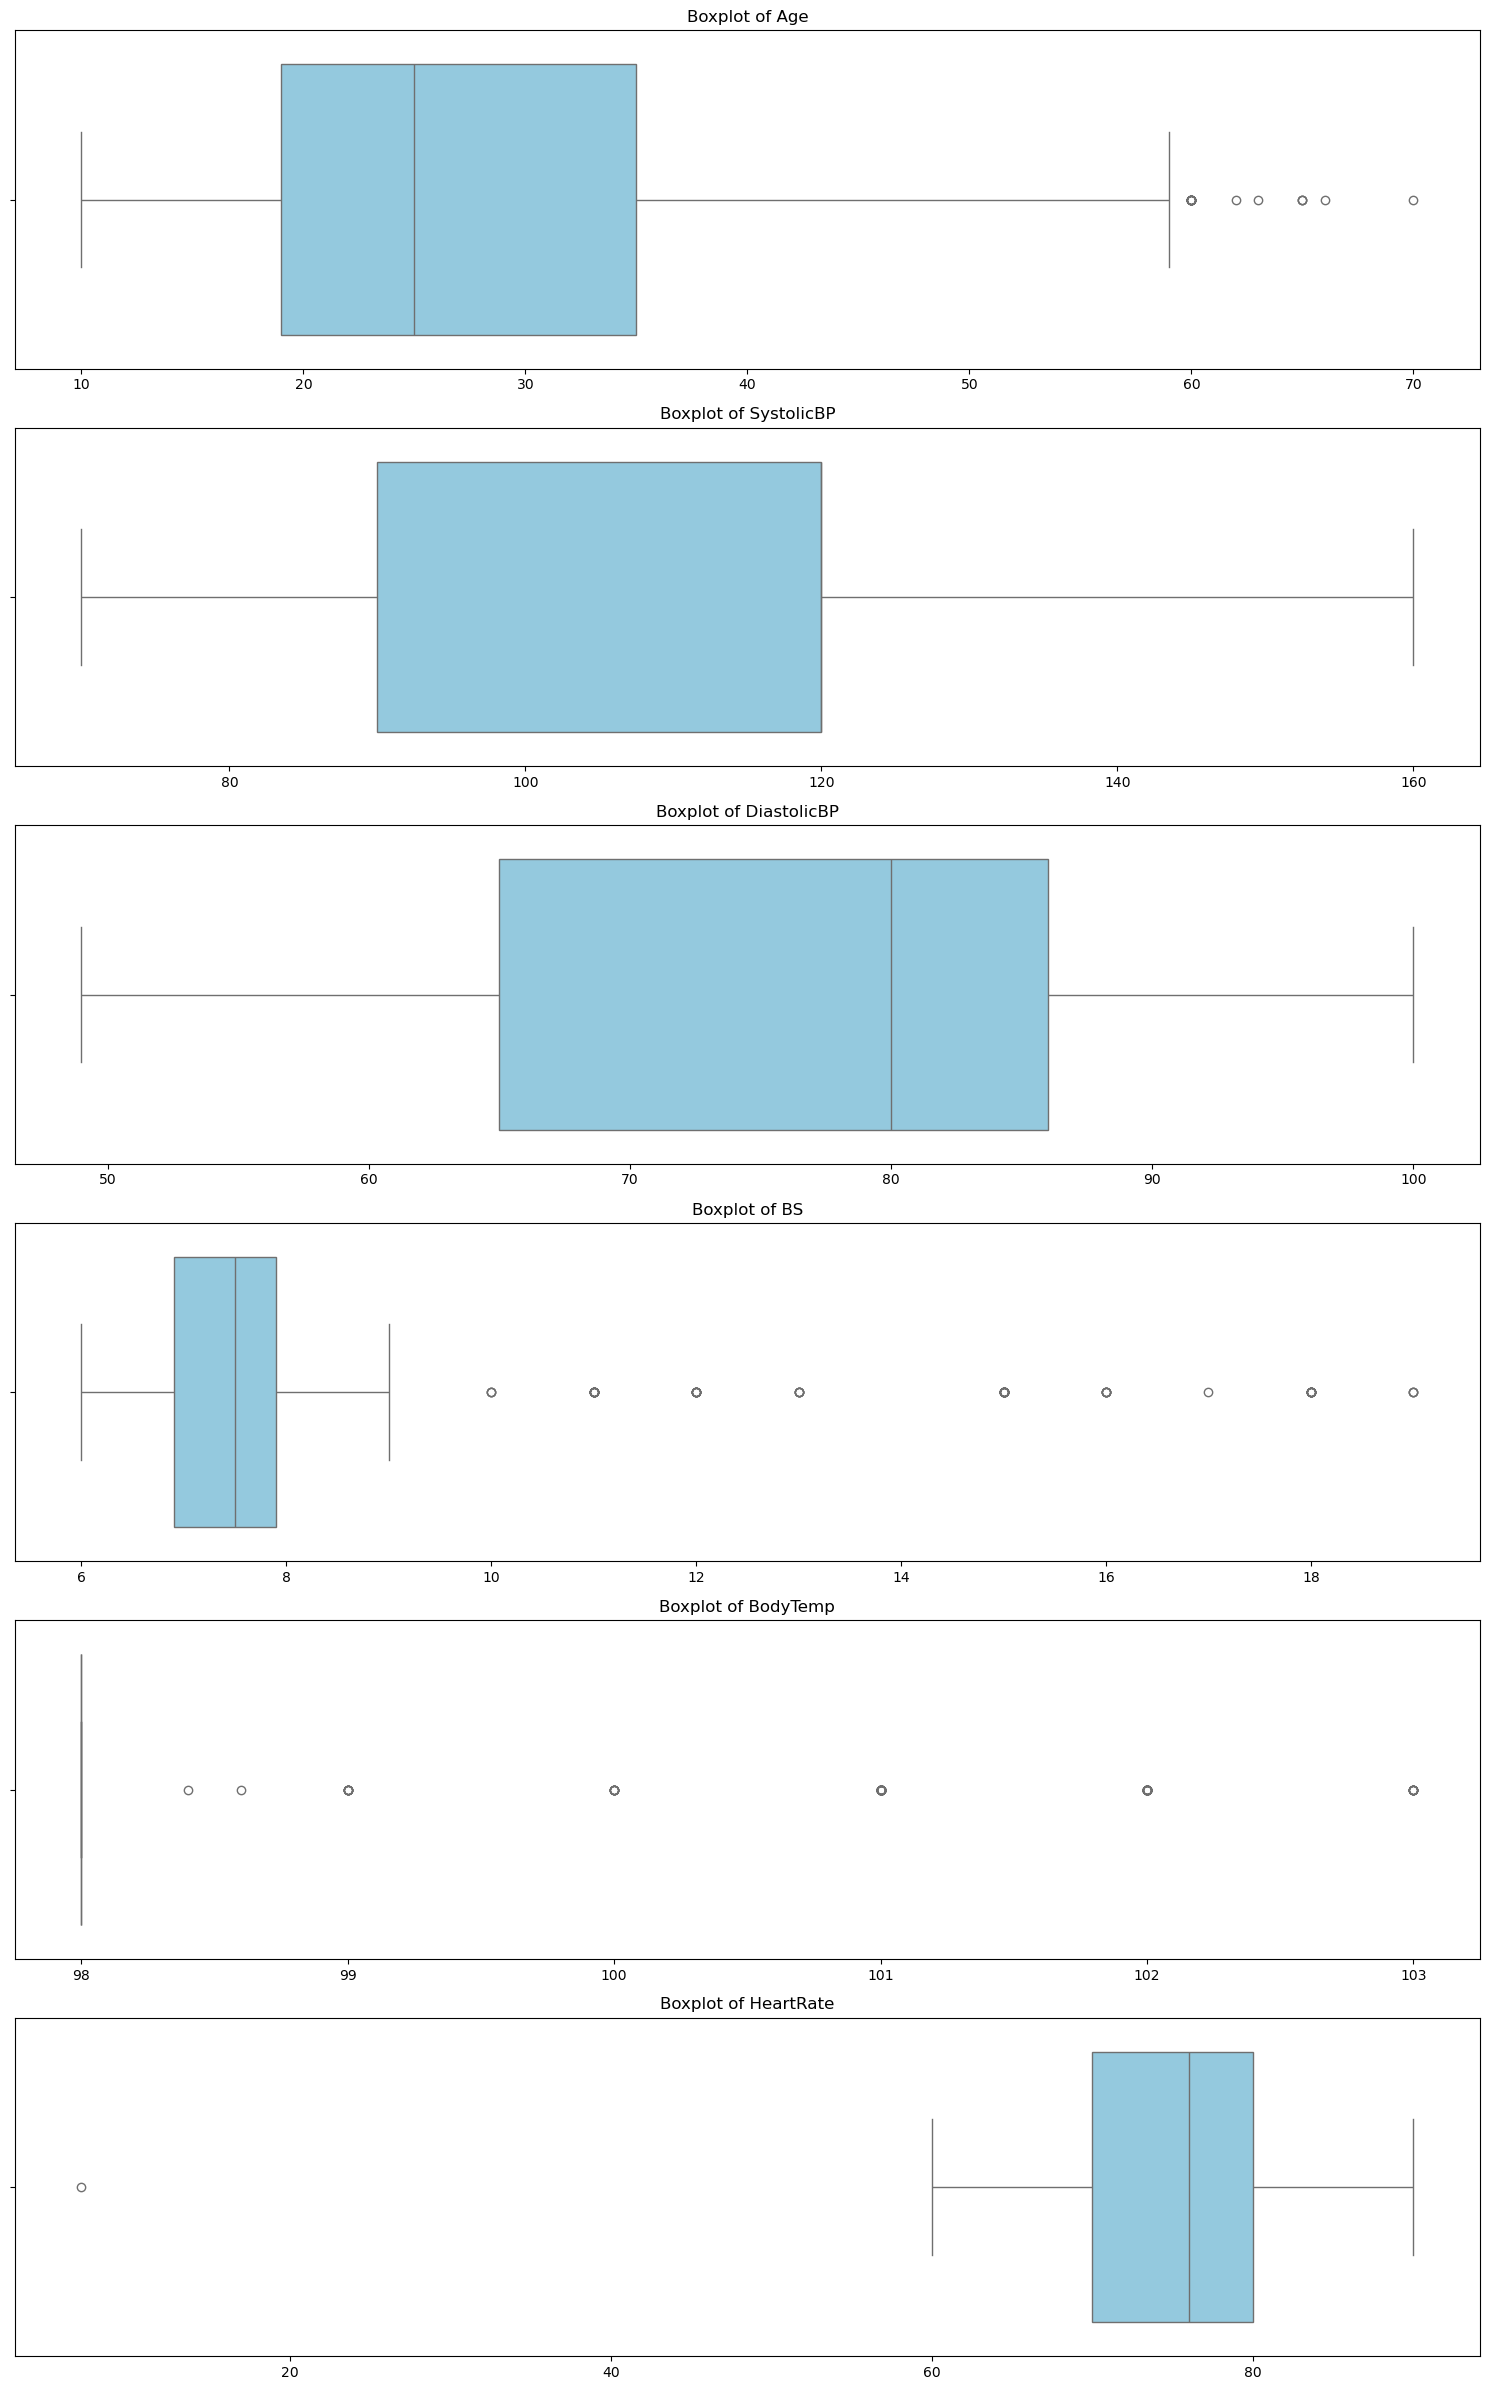

In [ ]:
# Select only the numerical columns from the dataset
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set the overall figure size based on the number of numeric columns
plt.figure(figsize=(15, len(numeric_cols) * 4))

# Plot a boxplot for each numerical column
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()


## Variable Trends by Risk Level
##### Age:
- High risk patients tend to be older.
- Low risk patients are generally younger.
- Age is a significant predictor of maternal health risk.

##### SystolicBP:
- Elevated systolic pressure is a strong risk indicator.

##### DiastolicBP:
- May play a supporting role in risk classification.

##### Blood Sugar (BS):
- High blood sugar is linked to critical maternal conditions.

##### Body Temperature:
- Fever may indicate worsening health.

##### Heart Rate:
- High hart rate reflects physiological stress .

In [ ]:
dfcof=df.copy()
dfcof['RiskLevel'] = dfcof['RiskLevel'].map({'low risk': 0, 'mid risk': 1, 'high risk': 2})
dfcof.corr()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
Age,1.000000,0.375931,0.347846,0.376616,-0.188843,0.077407,0.183010
SystolicBP,0.375931,1.000000,0.790002,0.347534,-0.207267,-0.006088,0.327365
DiastolicBP,0.347846,0.790002,1.000000,0.300423,-0.201992,-0.016470,0.254239
BS,0.376616,0.347534,0.300423,1.000000,-0.042511,0.135605,0.548888
BodyTemp,-0.188843,-0.207267,-0.201992,-0.042511,1.000000,0.087262,0.259701
HeartRate,0.077407,-0.006088,-0.016470,0.135605,0.087262,1.000000,0.183289
RiskLevel,0.183010,0.327365,0.254239,0.548888,0.259701,0.183289,1.000000


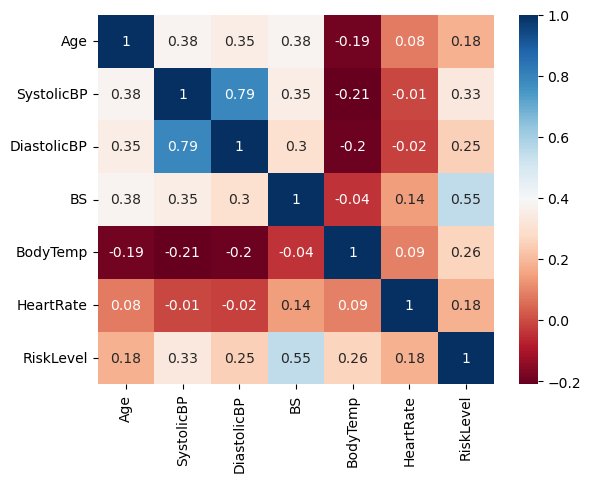

In [ ]:
corrHeatMap = dfcof.corr().round(2)
sns.heatmap(corrHeatMap, cmap='RdBu', annot=True)
plt.show()

In [ ]:
# we found that age and HeartRate is converted to float.Because df.corr() always returns correlation values as float
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [ ]:
df['Age'] = df['Age'].astype('int64')
df['HeartRate'] = df['HeartRate'].astype('int64')
df.dtypes

Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object

In [ ]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Function to handle outliers in each column
def replace_outliers_with_mean(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mean_val = series.mean()

    # Replace values outside the IQR range with the column mean
    return series.apply(lambda x: mean_val if (x < lower or x > upper) else x)

# Apply the outlier handling function to each numeric column
for col in numeric_cols:
    df[col] = replace_outliers_with_mean(df[col])

# Print the list of numeric columns
print(list(numeric_cols))


['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']


we learned IQR to solve all outlier for eche attribute [here](https://youtu.be/A3gClkblXK8).

and we need a way to apply Replace so we use Lambda Function[here](https://www.youtube.com/watch?v=6X6A8M2-Avg)

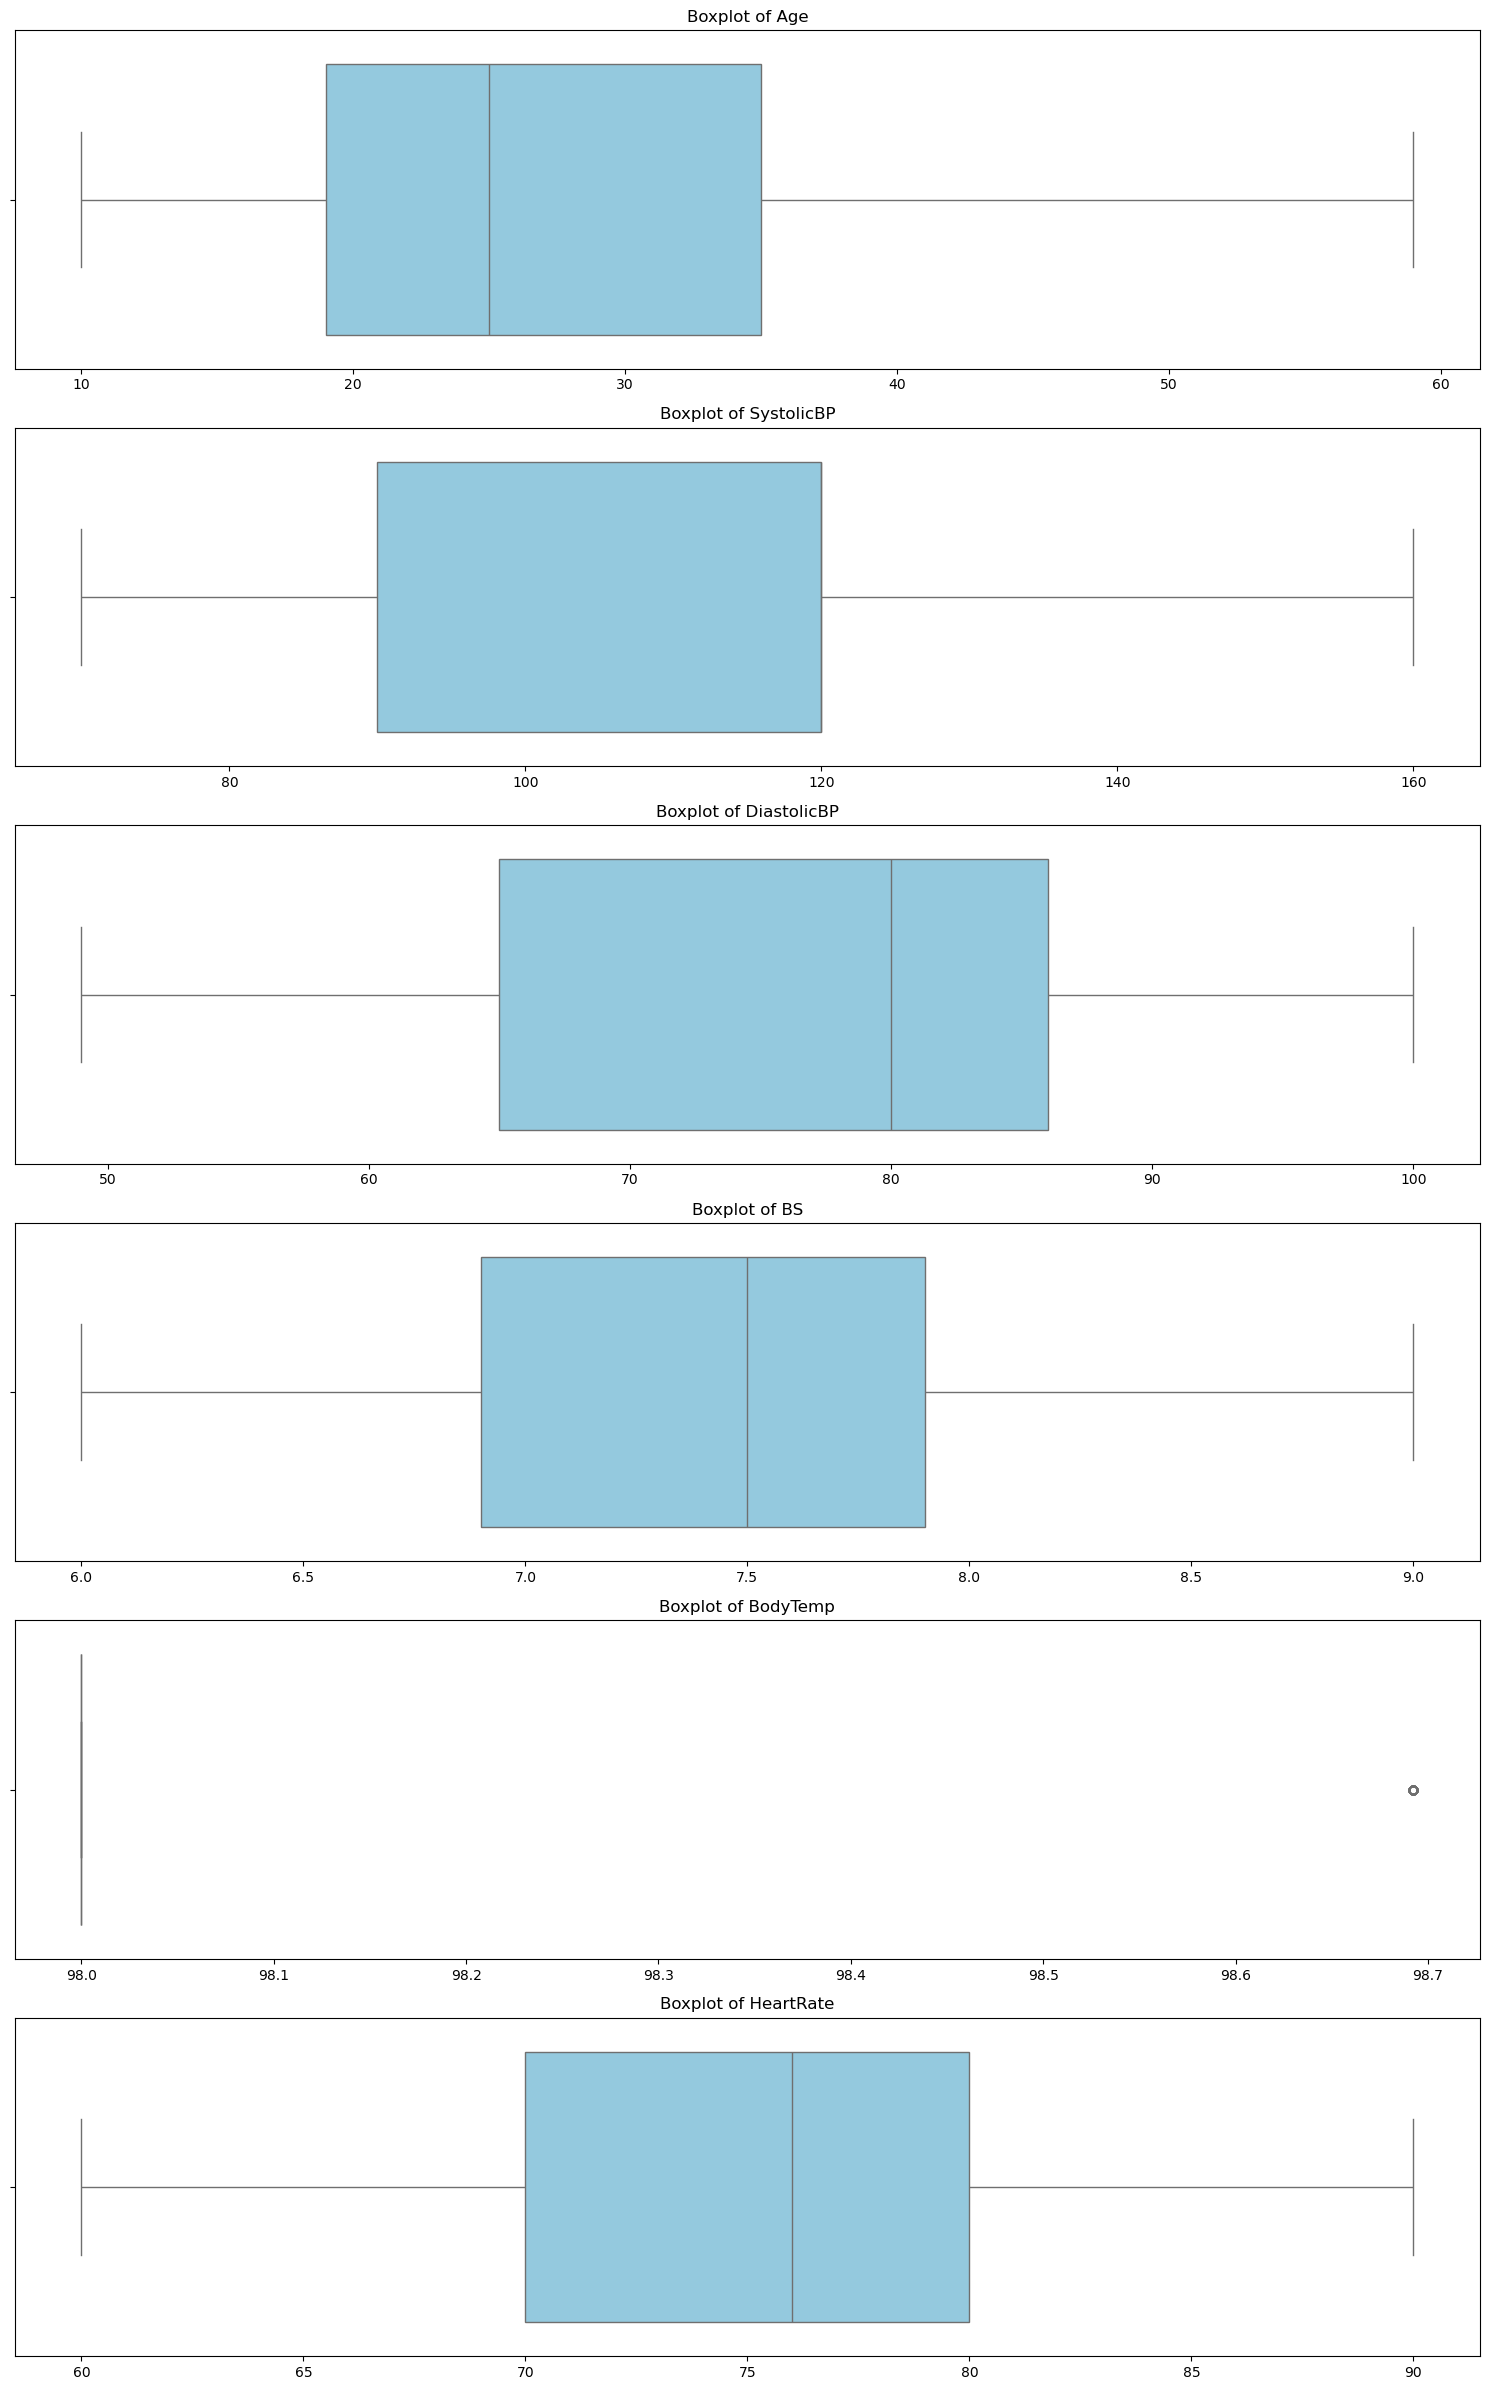

In [ ]:
# Select only the numerical columns from the dataset
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set the overall figure size based on the number of numeric columns
plt.figure(figsize=(15, len(numeric_cols) * 4))

# Plot a boxplot for each numerical column
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel('')

plt.tight_layout()
plt.show()

These visualizations show the distribution of each variable (SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate)
after replacing extreme values using domain specific thresholds and IQR based logic.
The plots confirm that most outliers have been handled, BodyTemp values are in Fahrenheit and 98°F is within the normal range 96-99°F so it is NOT an outlier and does not need modification.

In [ ]:
print(df['RiskLevel'].value_counts())

RiskLevel
low risk     234
high risk    112
mid risk     106
Name: count, dtype: int64


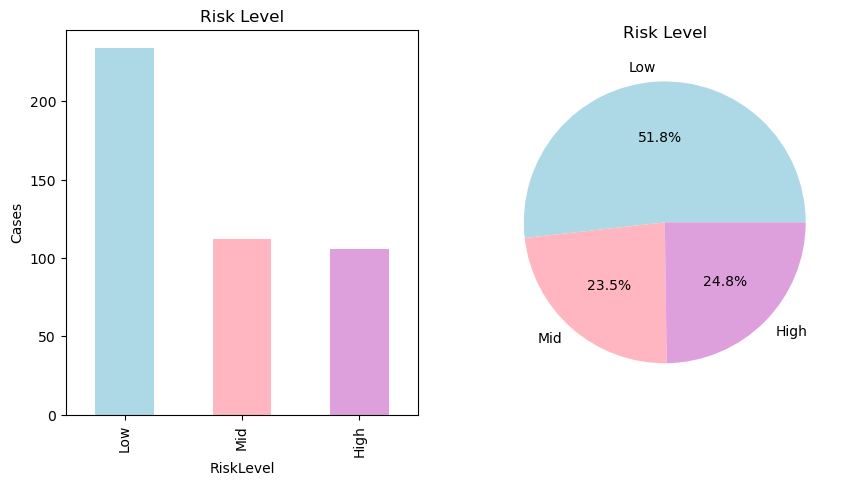

In [ ]:
# Plot bar and pie charts for the target variable
low = 234
mid = 106
high = 112

labels = ["Low", "Mid", "High"]
color1 = ["lightblue", "lightpink", "plum"]

plt.subplot(1,2,1)
vis = df.RiskLevel.value_counts().plot(
    figsize=(10, 5),
    kind="bar",
    color=color1,
)
plt.title("Risk Level")
plt.ylabel("Cases")
plt.xticks(range(len(labels)), labels)

plt.subplot(1,2,2)
plt.title("Risk Level")
vis = plt.pie(
    [low, mid, high],
    labels=labels,
    colors=color1,
    autopct="%1.1f%%",
)
plt.show()

In [ ]:
def preprocess_features(X_data):
    # Applies Min Max Scaling to numerical features and One Hot Encoding to categorical features.
    X = X_data.copy()

    # Identify column types
    numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = X.select_dtypes(include=['object', 'category']).columns

    #  Apply MinMaxScaler to numerical columns
    if len(numerical_cols) > 0:
        scaler = MinMaxScaler()
        X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

    # Apply OneHotEncoder to categorical columns
    if len(categorical_cols) > 0:
        encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

        # Encode categorical columns
        encoded_cols = encoder.fit_transform(X[categorical_cols])

        encoded_df = pd.DataFrame(encoded_cols,
                                  columns=encoder.get_feature_names_out(categorical_cols),
                                  index=X.index)

        # Drop original categorical columns
        X = X.drop(categorical_cols, axis=1)

        # Concatenate the encoded columns with the original DataFrame
        X = pd.concat([X, encoded_df], axis=1)

    return X


In [ ]:
#  Separate features X  from the target variable  y
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Then apply preprocess_data only to the feature set
X_processed = preprocess_features(X)

#  Encode categorical target labels (high risk, low risk, mid risk) into numeric values (0, 1, 2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Target y after Label Encoding :")
print(y_encoded[:15])

#  Apply SMOTETomek to balance the dataset and remove overlapping samples
# SMOTE generates synthetic samples for minority classes
# Tomek Links removes ambiguous samples near decision boundaries
smt = SMOTETomek(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled_encoded = smt.fit_resample(X, y_encoded)

#  the new class distribution after resampling
unique, counts = np.unique(y_resampled_encoded, return_counts=True)
print("Distribution of RiskLevel after SMOTETomek:")
for label, count in zip(le.inverse_transform(unique), counts):
    print(f"{label}: {count}")



Target y after Label Encoding :
[0 0 0 0 1 0 2 0 2 0 1 2 1 2 2]
Distribution of RiskLevel after SMOTETomek:
high risk: 224
low risk: 219
mid risk: 223


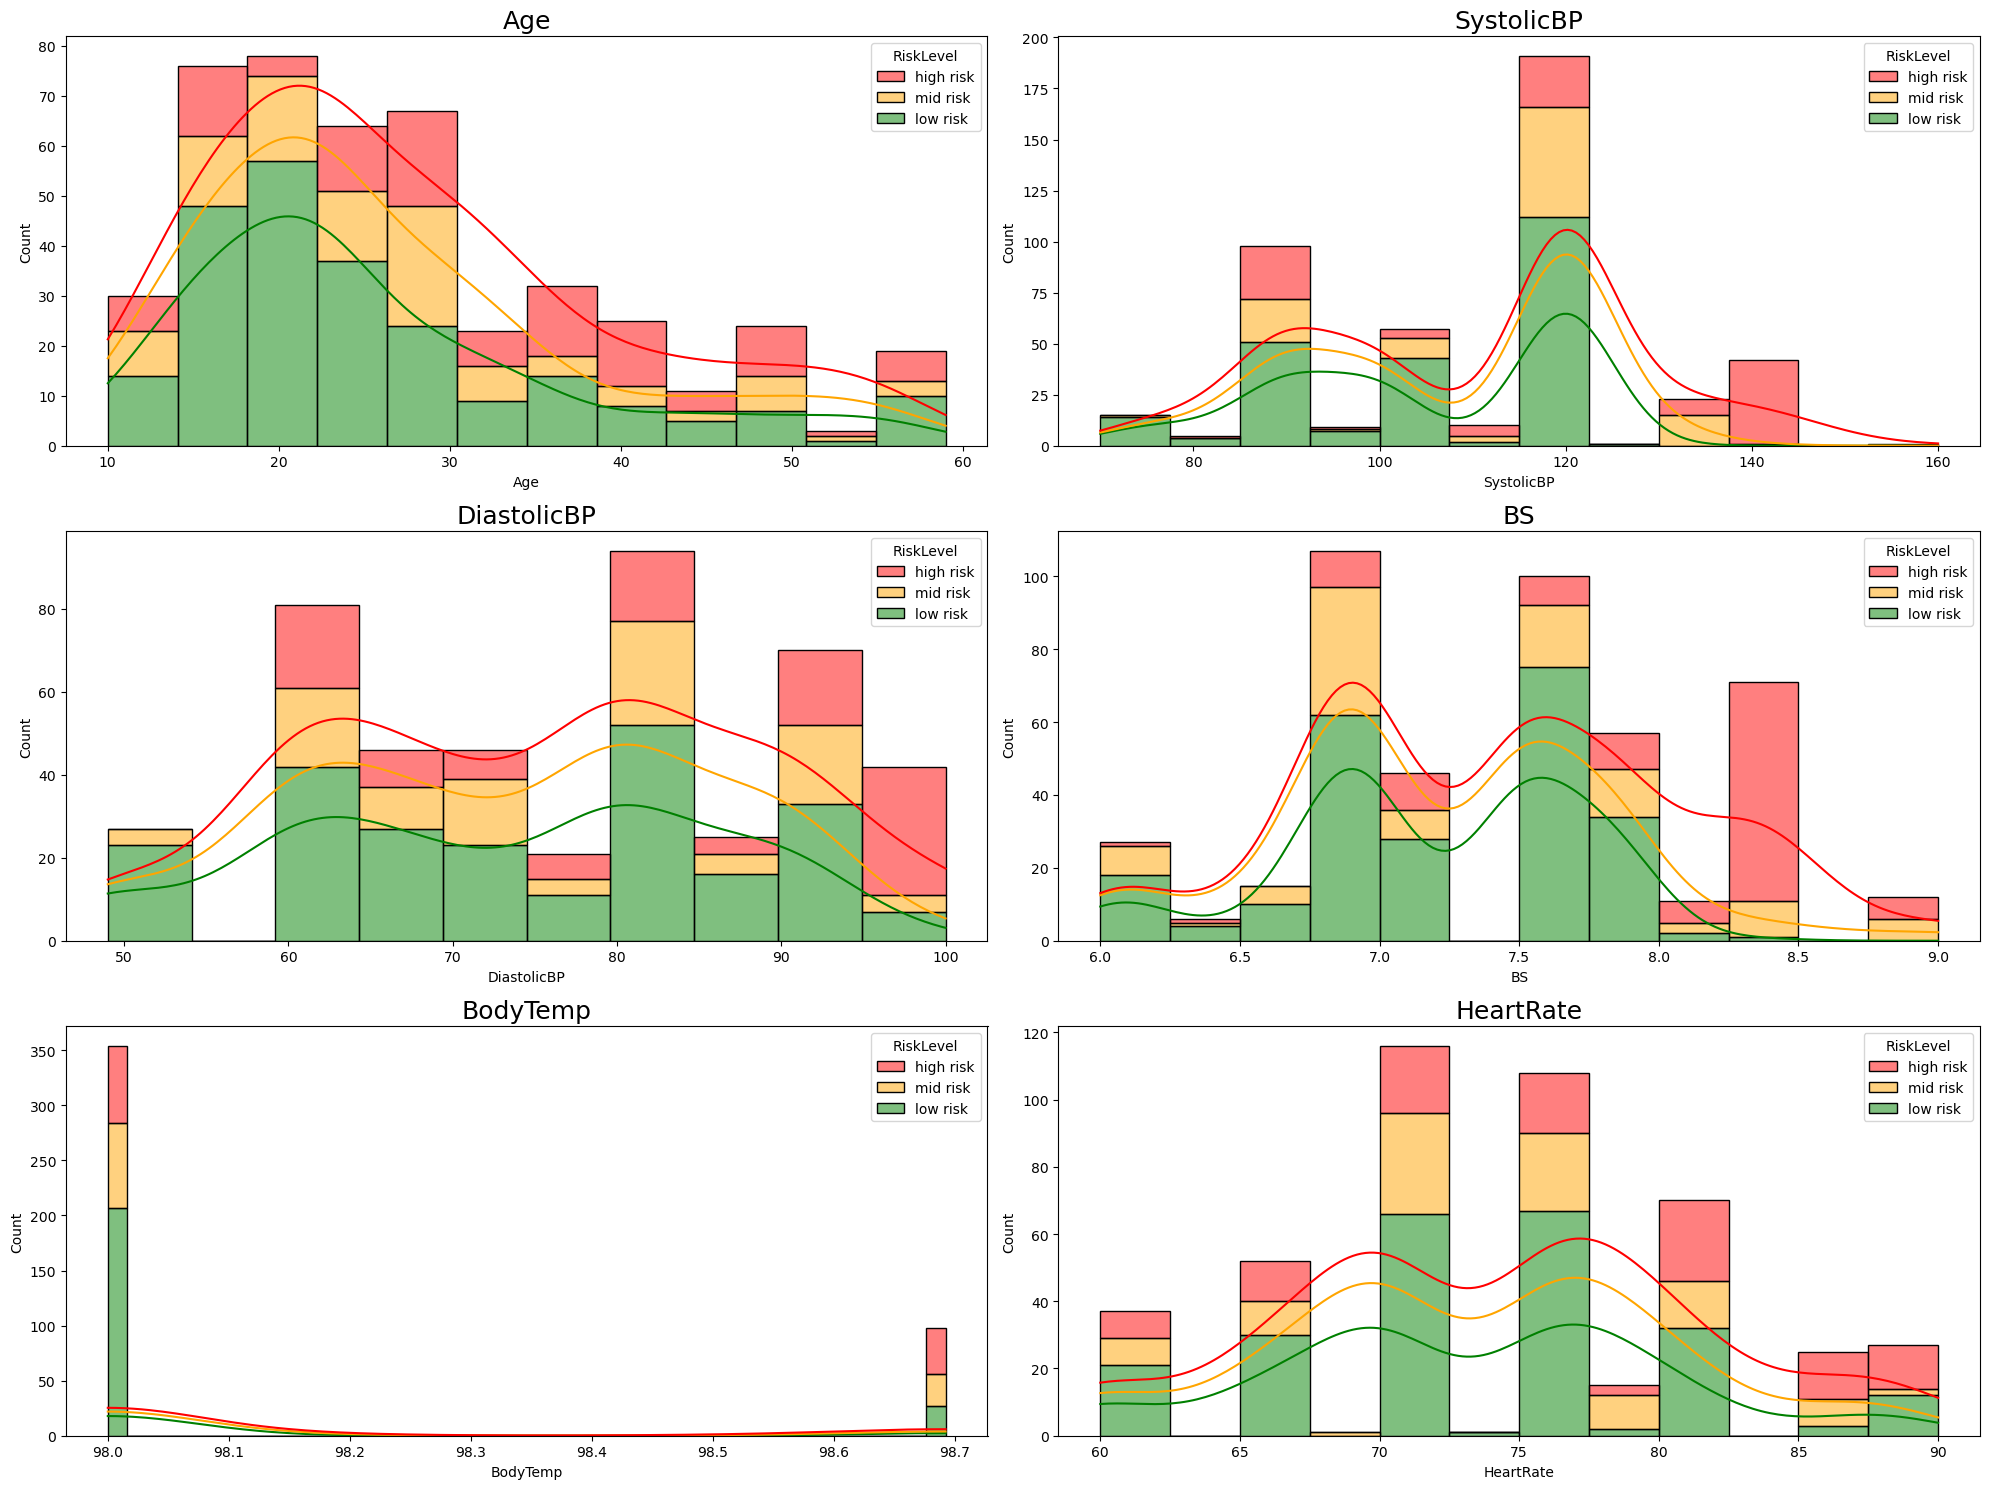

In [ ]:
# Plot stacked histograms
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(20, 15))
risk_level_order = ["high risk", "mid risk", "low risk"]

for ax, column in zip(axes.flatten(), df.columns):
    sns.histplot(data=df,
                 x=column,
                 kde=True,
                 hue="RiskLevel",
                 hue_order=risk_level_order,
                 multiple="stack",
                 palette={"low risk": "green", "mid risk": "orange", "high risk": "red"},
                 element="bars", ax=ax)
    ax.set_title(f"{column}", fontsize=18)

plt.tight_layout()
plt.show()

we use zip function as we learn from [here](https://www.techsyncer.com/ar/python-zip-function-explained-with-examples.html)

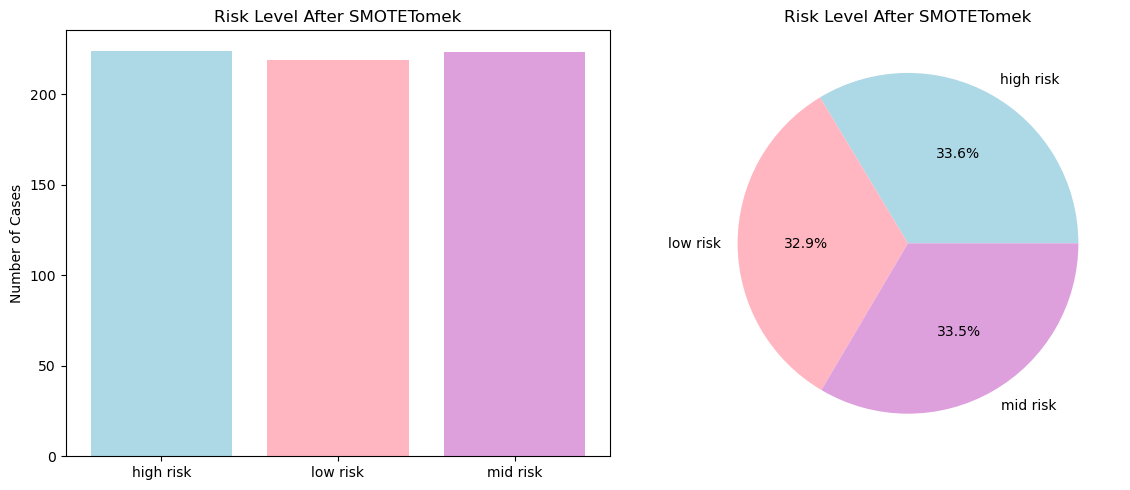

In [ ]:
# we count the number of cases in each class after applying SMOTE
unique_classes, counts = np.unique(y_resampled_encoded, return_counts=True)

# Prepare labels and colors for visualization
labels = le.inverse_transform(unique_classes)  # We convert encoded labels back to original category names
colors = ["lightblue", "lightpink", "plum"]

# Bar Chart
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(labels, counts, color=colors)
plt.title("Risk Level After SMOTETomek")
plt.ylabel("Number of Cases")

#  Pie Chart
plt.subplot(1, 2, 2)
plt.pie(counts, labels=labels, colors=colors, autopct="%1.1f%%")
plt.title("Risk Level After SMOTETomek")

plt.tight_layout()
plt.show()

C:\Users\ghada\AppData\Local\Temp\ipykernel_31932\2145582855.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x=x_var, y=y_var, ci=None, ax=ax)
C:\Users\ghada\AppData\Local\Temp\ipykernel_31932\2145582855.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x=x_var, y=y_var, ci=None, ax=ax)
C:\Users\ghada\AppData\Local\Temp\ipykernel_31932\2145582855.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x=x_var, y=y_var, ci=None, ax=ax)
C:\Users\ghada\AppData\Local\Temp\ipykernel_31932\2145582855.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x=x_var, y=y_var, ci=None, ax=ax)
C:\Users\ghada\AppData\Local\Temp\ipykernel_31932\2145582855.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `

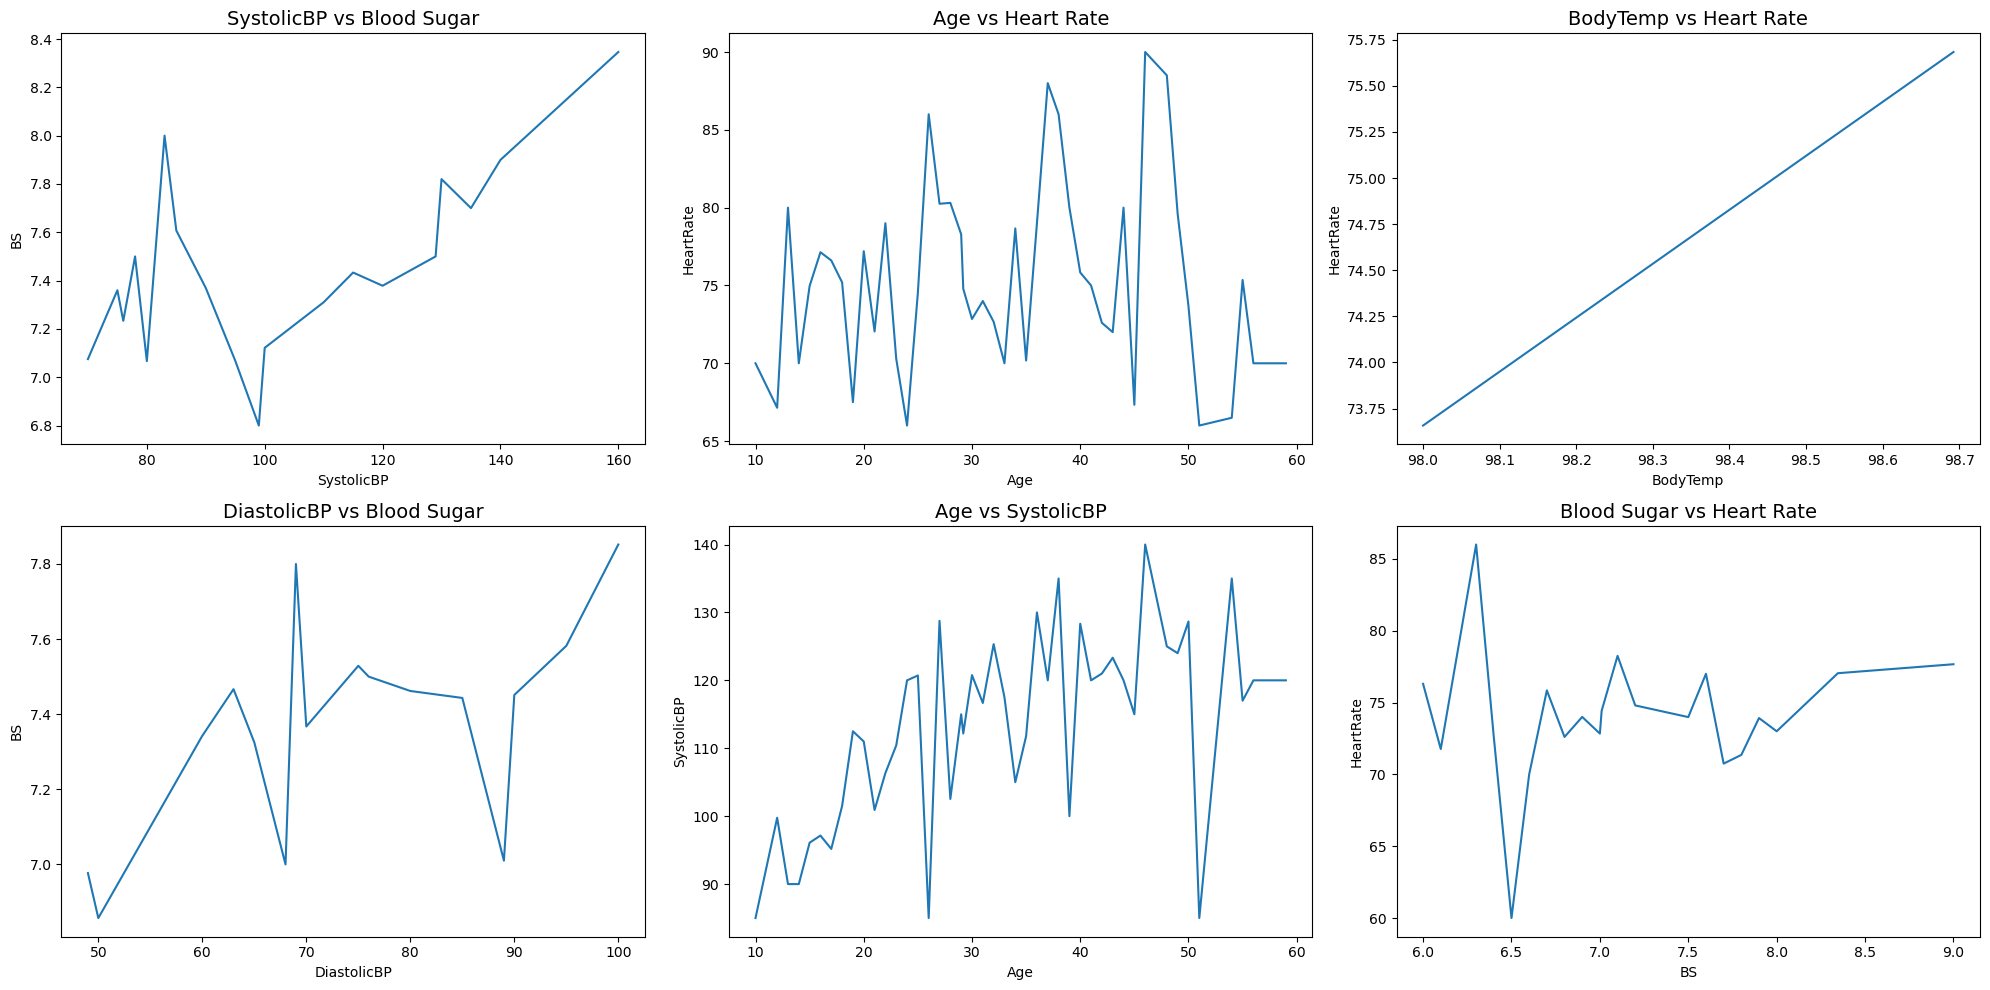

In [ ]:
# Set up a 2x3 grid for subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

variables = [
    ('SystolicBP', 'BS', "SystolicBP vs Blood Sugar"),
    ('Age', 'HeartRate', "Age vs Heart Rate"),
    ('BodyTemp', 'HeartRate', "BodyTemp vs Heart Rate"),
    ('DiastolicBP', 'BS', "DiastolicBP vs Blood Sugar"),
    ('Age', 'SystolicBP', "Age vs SystolicBP"),
    ('BS', 'HeartRate', "Blood Sugar vs Heart Rate")
]

# Generate a line plot for each variable pair
for ax, (x_var, y_var, title) in zip(axes.flatten(), variables):
    sns.lineplot(data=df, x=x_var, y=y_var, ci=None, ax=ax)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)

plt.tight_layout()
plt.show()


- SystolicBP vs Blood Sugar A clear positive correlation: as blood sugar increases, systolic blood pressure tends to rise. This suggests that elevated glucose levels may be associated with higher blood pressure.

- Age vs Heart Rate The distribution is scattered with no clear trend. This indicates that age does not directly influence heart rate in this dataset, or the relationship may be nonlinear.

- Body Temperature vs Heart Rate A strong linear relationship: as body temperature increases, heart rate increases proportionally which is a normal response.

- DiastolicBP vs Blood Sugar The relationship is weak and scattered. There’s no consistent pattern, suggesting a low or indirect correlation between diastolic pressure and blood sugar.

- Age vs SystolicBP The points are widely spread with no clear direction. Age doesn’t appear to directly determine systolic blood pressure, and other factors may be involved.

- Blood Sugar vs Heart Rate The relationship is unstable with fluctuations. No clear trend is observed, but there may be a nonlinear or confounded relationship.

### K-Nearest Neighbors (KNN) Model Building

In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled_encoded, test_size=0.2, random_state=42)


In [ ]:
# Create and train the KNN model using 3 neighbors
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_knn = knn_model.predict(X_test)

In [ ]:
#Evaluate the KNN Model
print("KNN Model Results")

#Calculate the accuracy of the KNN model
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

#Print a detailed classification report (precision, recall, f1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))

KNN Model Results
Accuracy: 0.6791044776119403

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.80      0.77        45
           1       0.66      0.66      0.66        44
           2       0.62      0.58      0.60        45

    accuracy                           0.68       134
   macro avg       0.68      0.68      0.68       134
weighted avg       0.68      0.68      0.68       134



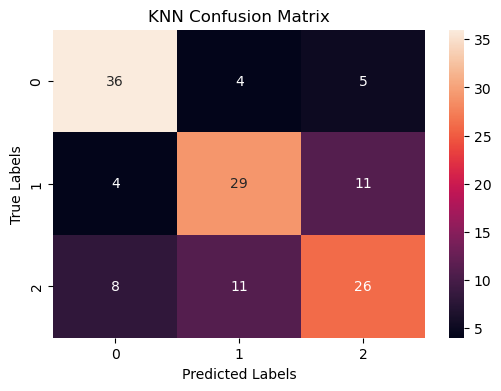

In [ ]:
# Generate the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Naïve Bayes(NB)Model Building


In [ ]:
# Create and train Naive Bayes model
model_nb = GaussianNB()
model_nb.fit(X_train, y_train)

# Predict on test data
y_pred_nb = model_nb.predict(X_test)

In [ ]:
#Evaluate the Naïve Bayes model
print("Naïve Bayes Results")

#Calculate and print the accuracy of the Naïve Bayes model
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

#Display a detailed classification report (includes precision, recall, and F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

Naïve Bayes Results
Accuracy: 0.6044776119402985

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.73      0.73        45
           1       0.64      0.68      0.66        44
           2       0.44      0.40      0.42        45

    accuracy                           0.60       134
   macro avg       0.60      0.61      0.60       134
weighted avg       0.60      0.60      0.60       134



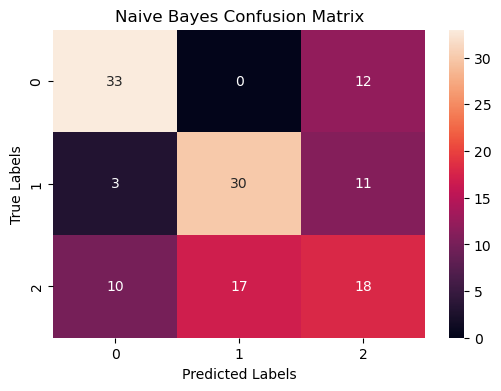

In [ ]:
# Generate the confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_nb, annot=True)
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Random Forset(RF) Model Building

In [ ]:
# Create and train the Random Forest model
RF = RandomForestClassifier(n_estimators=100, random_state=0)
RF.fit(X_train, y_train)

# Predict on test data
y_pred_rf = RF.predict(X_test)

In [ ]:
# Evaluate the Random Forest model
print("Random Forest Results")

# Print the accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Print detailed classification report (precision, recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.7761194029850746

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91        45
           1       0.66      0.86      0.75        44
           2       0.79      0.58      0.67        45

    accuracy                           0.78       134
   macro avg       0.79      0.78      0.77       134
weighted avg       0.79      0.78      0.77       134



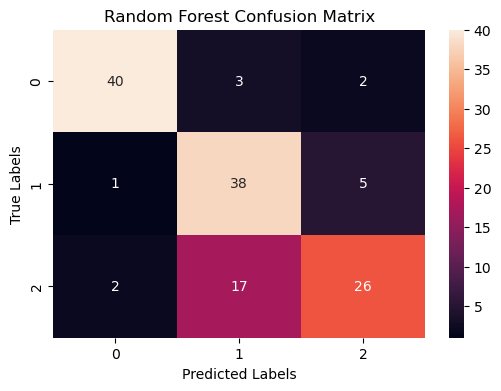

In [ ]:
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Decision Tree Model Bulidong

In [ ]:
# Build the Decision Tree
decisionTree = DecisionTreeClassifier(criterion="entropy", max_depth=4)
decisionTree.fit(X_train, y_train)

# Predict on Test Data
y_pred_Tree = decisionTree.predict(X_test)

# Evaluate the Decision Tree Model
print("Decision Tree Results")

# Print the accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_Tree))

print("\nDecision Tree Classification Report:\n",classification_report(y_test, y_pred_Tree, target_names=le.classes_))

Decision Tree Results
Accuracy: 0.6865671641791045

Decision Tree Classification Report:
               precision    recall  f1-score   support

   high risk       0.80      0.73      0.77        45
    low risk       0.64      0.95      0.76        44
    mid risk       0.63      0.38      0.47        45

    accuracy                           0.69       134
   macro avg       0.69      0.69      0.67       134
weighted avg       0.69      0.69      0.67       134



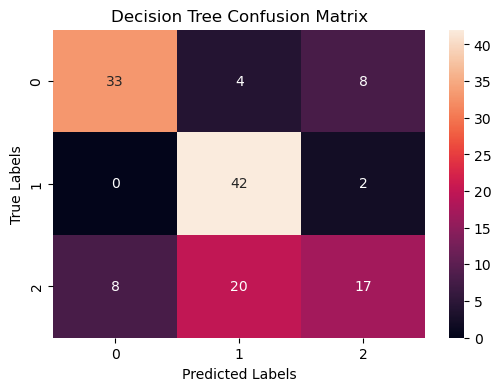

In [ ]:
# Generate the confusion matrix for Decision Tree ---
cm_tree = confusion_matrix(y_test, y_pred_Tree)

# visualize the confusion matrix using a heatmap ---
plt.figure(figsize=(6,4))
sns.heatmap(cm_tree, annot=True)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


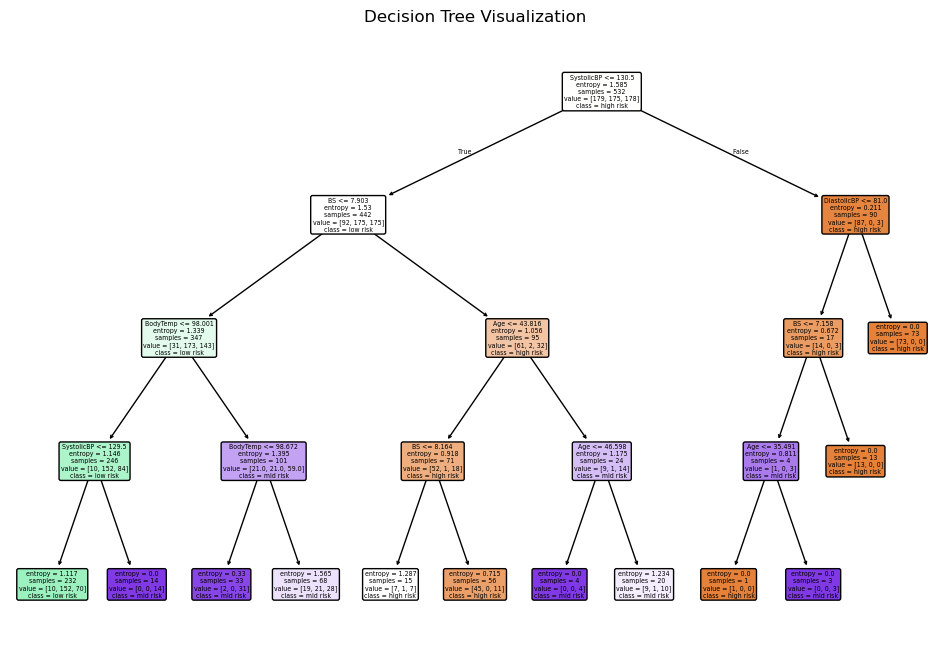

In [ ]:
# Visualize the Decision Tree
plt.figure(figsize=(12,8))
plot_tree(decisionTree,
          feature_names=X_train.columns,
          class_names=le.classes_,
          filled=True,
          rounded=True)
plt.title("Decision Tree Visualization")
plt.show()

# support Vector(SVM) Model Bulidong

In [ ]:
# Create and train the SVM model
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Predict on test data
y_pred_svm = svm_model.predict(X_test)

In [ ]:
# Evaluate the SVM Model
print("SVM Model Results")

# Calculate and print the accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

# Print detailed classification report (precision, recall, F1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

SVM Model Results
Accuracy: 0.4701492537313433

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.27      0.40        45
           1       0.41      0.55      0.47        44
           2       0.45      0.60      0.51        45

    accuracy                           0.47       134
   macro avg       0.55      0.47      0.46       134
weighted avg       0.55      0.47      0.46       134



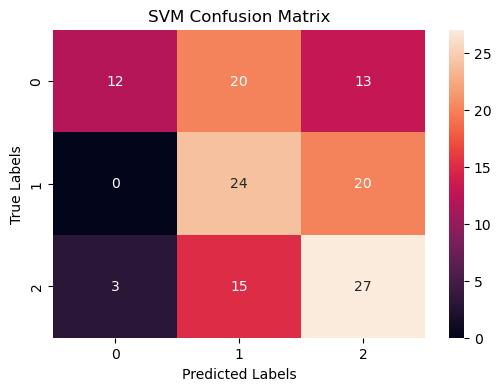

In [ ]:
# Generate the confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Artificial Neural Network (ANN) Model Bulidong

In [ ]:
# Bulidong Model
ann_model = Sequential()

# Input layer + first hidden layer
ann_model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))

# Second hidden layer
ann_model.add(Dense(16, activation='relu'))

#3 hidden layer
ann_model.add(Dense(8, activation='relu'))

# Output layer with softmax for multiclass classification
ann_model.add(Dense(len(le.classes_), activation='softmax'))

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Train the ANN model
h = ann_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)
#predict
y_pred_ann_probs = ann_model.predict(X_test)
y_pred_ann = y_pred_ann_probs.argmax(axis=1)

print("ANN Model Results")
print("Accuracy:", accuracy_score(y_test, y_pred_ann))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ann))

C:\Users\ghada\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
ANN Model Results
Accuracy: 0.5522388059701493

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.47      0.59        45
           1       0.51      0.93      0.66        44
           2       0.44      0.27      0.33        45

    accuracy                           0.55       134
   macro avg       0.59      0.56      0.53       134
weighted avg       0.59      0.55      0.53       134



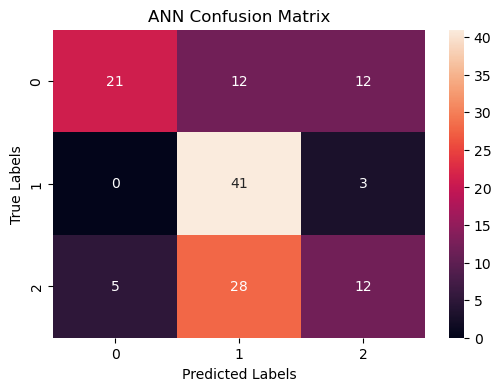

In [ ]:
# Generate the confusion matrix
cm_ann = confusion_matrix(y_test, y_pred_ann)

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm_ann, annot=True)
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

we learn how to builid from [here](https://youtu.be/8zwILUzux6o?si=GfoGZs0PqNEN8O1h)

# ROC Curves Model Performance

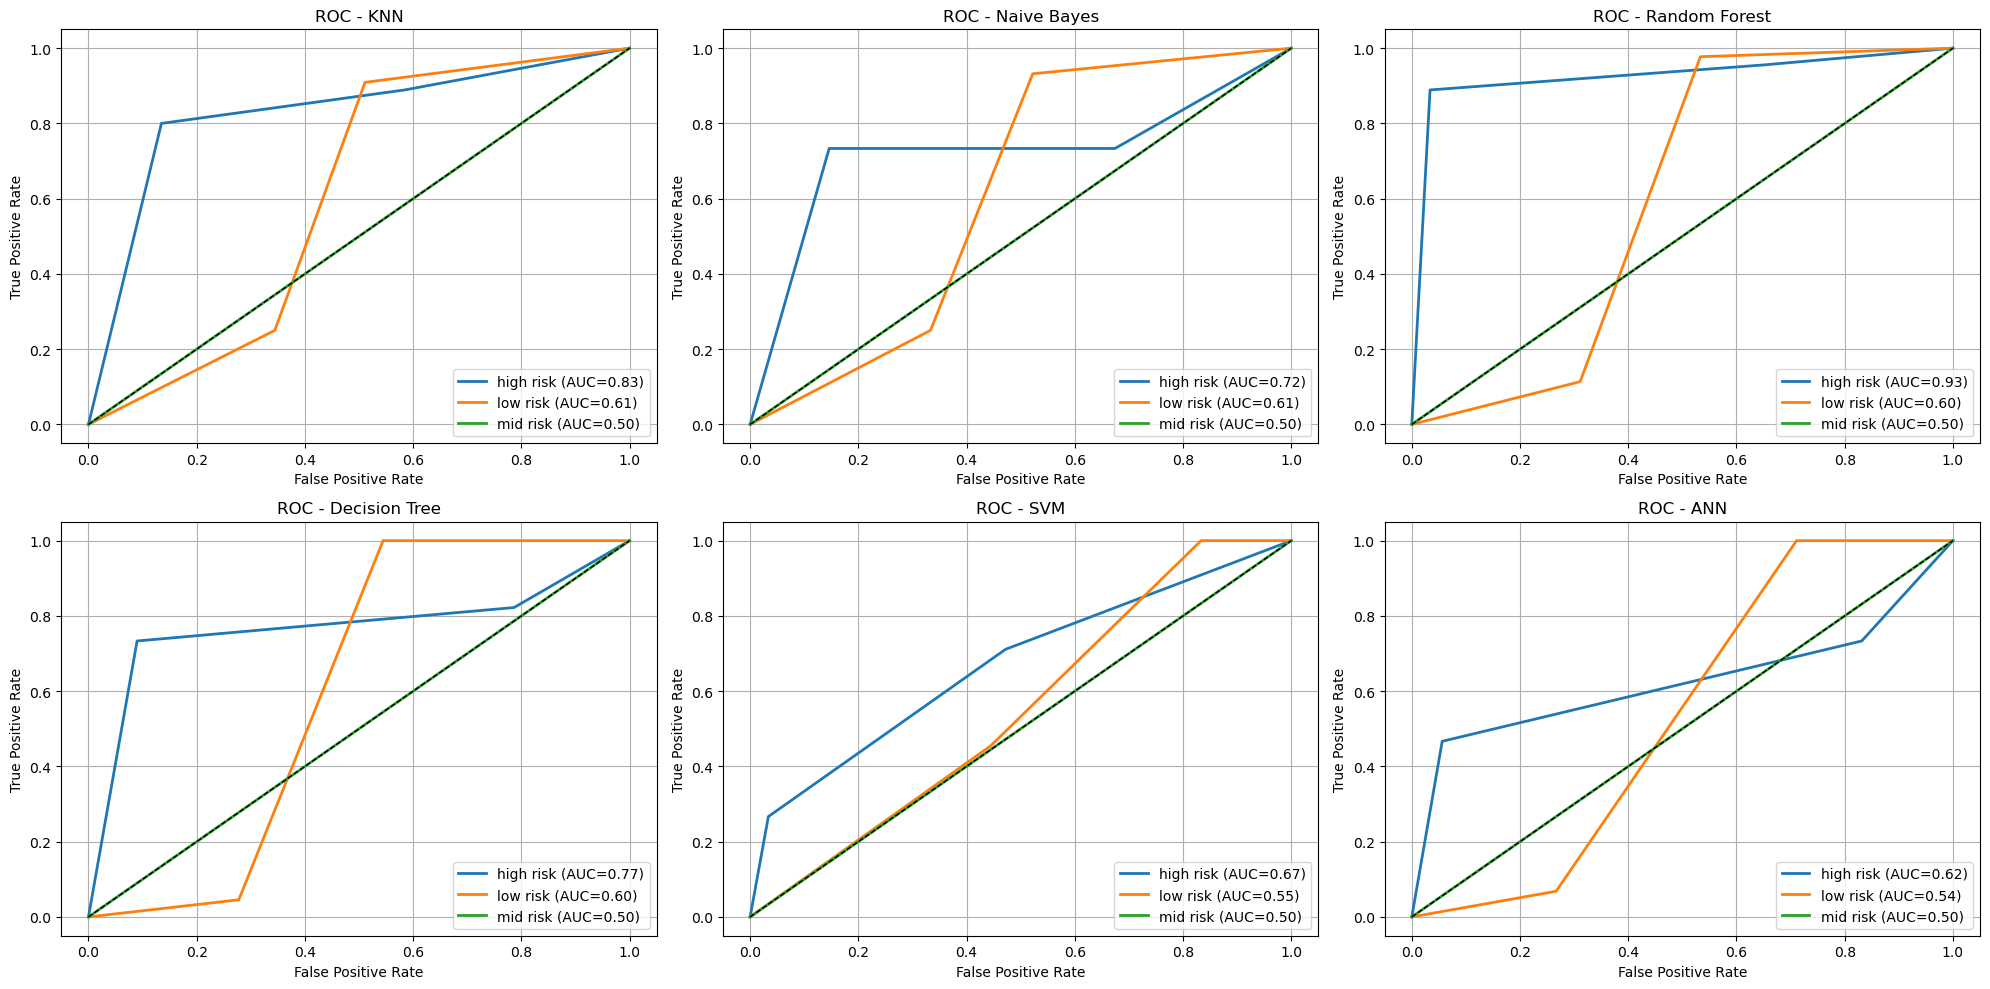

In [ ]:
# Binarize the target for multiclass ROC
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Use previously computed predicted probabilities
models_probs = {
    'KNN': y_pred_knn,
    'Naive Bayes': y_pred_nb,
    'Random Forest': y_pred_rf,
    'Decision Tree': y_pred_Tree,
    'SVM': y_pred_svm,
    'ANN': y_pred_ann
}

# Create subplots: 2 rows x 3 columns
plt.figure(figsize=(20,10))

for i, (model_name, y_probs) in enumerate(models_probs.items(), 1):
    plt.subplot(2, 3, i)

    # Ensure y_probs is 2D and has n_classes columns
    if y_probs.ndim == 1:  # Convert 1D to 2D for binary case
        y_probs = np.column_stack([1 - y_probs, y_probs])
    if y_probs.shape[1] < n_classes:  # Pad missing columns with zeros
        missing_cols = n_classes - y_probs.shape[1]
        y_probs = np.hstack([y_probs, np.zeros((y_probs.shape[0], missing_cols))])

    # Plot ROC for each class
    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_probs[:, j])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{le.classes_[j]} (AUC={roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.title(f'ROC - {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Performance Comparison of Classification Models

In [ ]:
# Model Evaluation: Jaccard, F1-score and log loss

# KNN Model Evaluation
KNN_Jaccard = jaccard_score(y_test, y_pred_knn, average='weighted')
KNN_F1 = f1_score(y_test, y_pred_knn, average='weighted')
KNN_logloss = log_loss(y_test, knn_model.predict_proba(X_test))


# Naive Bayes Model Evaluation
NB_Jaccard = jaccard_score(y_test, y_pred_nb, average='weighted')
NB_F1 = f1_score(y_test, y_pred_nb, average='weighted')
NB_logloss = log_loss(y_test, model_nb.predict_proba(X_test))

# Decision Tree Model Evaluation
DT_Jaccard = jaccard_score(y_test, y_pred_Tree, average='weighted')
DT_F1 = f1_score(y_test, y_pred_Tree, average='weighted')
DT_logloss = log_loss(y_test, decisionTree.predict_proba(X_test))

# Random Forest Model Evaluation
RF_Jaccard = jaccard_score(y_test, y_pred_rf, average='weighted')
RF_F1 = f1_score(y_test, y_pred_rf, average='weighted')
RF_logloss = log_loss(y_test, RF.predict_proba(X_test))

# SVM Model Evaluation
SVM_Jaccard = jaccard_score(y_test, y_pred_svm, average='weighted')
SVM_F1 = f1_score(y_test, y_pred_svm, average='weighted')
SVM_logloss = log_loss(y_test, svm_model.predict_proba(X_test))

# ANN Model Evaluation
ANN_Jaccard = jaccard_score(y_test, y_pred_ann, average='weighted')
ANN_F1 = f1_score(y_test, y_pred_ann, average='weighted')
ANN_logloss = log_loss(y_test, y_pred_ann_probs)

In [ ]:
# Store metrics for each model
model_evaluations = {
    'KNN': {
        'Jaccard': round(KNN_Jaccard, 4),
        'F1-score': round(KNN_F1, 4),
        'LogLoss': round(KNN_logloss, 4)
    },
    'Naive Bayes': {
        'Jaccard': round(NB_Jaccard, 4),
        'F1-score': round(NB_F1, 4),
        'LogLoss': round(NB_logloss, 4)
    },
    'Decision Tree': {
        'Jaccard': round(DT_Jaccard, 4),
        'F1-score': round(DT_F1, 4),
        'LogLoss': round(DT_logloss, 4)
    },
    'Random Forest': {
        'Jaccard': round(RF_Jaccard, 4),
        'F1-score': round(RF_F1, 4),
        'LogLoss': round(RF_logloss, 4)
    },
    'SVM': {
        'Jaccard': round(SVM_Jaccard, 4),
        'F1-score': round(SVM_F1, 4),
        'LogLoss': round(SVM_logloss, 4)
    },
    'ANN': {
        'Jaccard': round(ANN_Jaccard, 4),
        'F1-score': round(ANN_F1, 4),
        'LogLoss': round(ANN_logloss, 4)
    },
}


In [ ]:
# Display metrics in a readable way
print("Model Comparison")
for model, metrics in model_evaluations.items():
    print(f"\n{model} Results:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value}")

Model Comparison

KNN Results:
Jaccard: 0.5166
F1-score: 0.6771
LogLoss: 3.0926

Naive Bayes Results:
Jaccard: 0.4415
F1-score: 0.6006
LogLoss: 0.7738

Decision Tree Results:
Jaccard: 0.5157
F1-score: 0.6671
LogLoss: 1.1976

Random Forest Results:
Jaccard: 0.6427
F1-score: 0.7738
LogLoss: 0.8156

SVM Results:
Jaccard: 0.3
F1-score: 0.4601
LogLoss: 1.0048

ANN Results:
Jaccard: 0.3685
F1-score: 0.526
LogLoss: 0.965


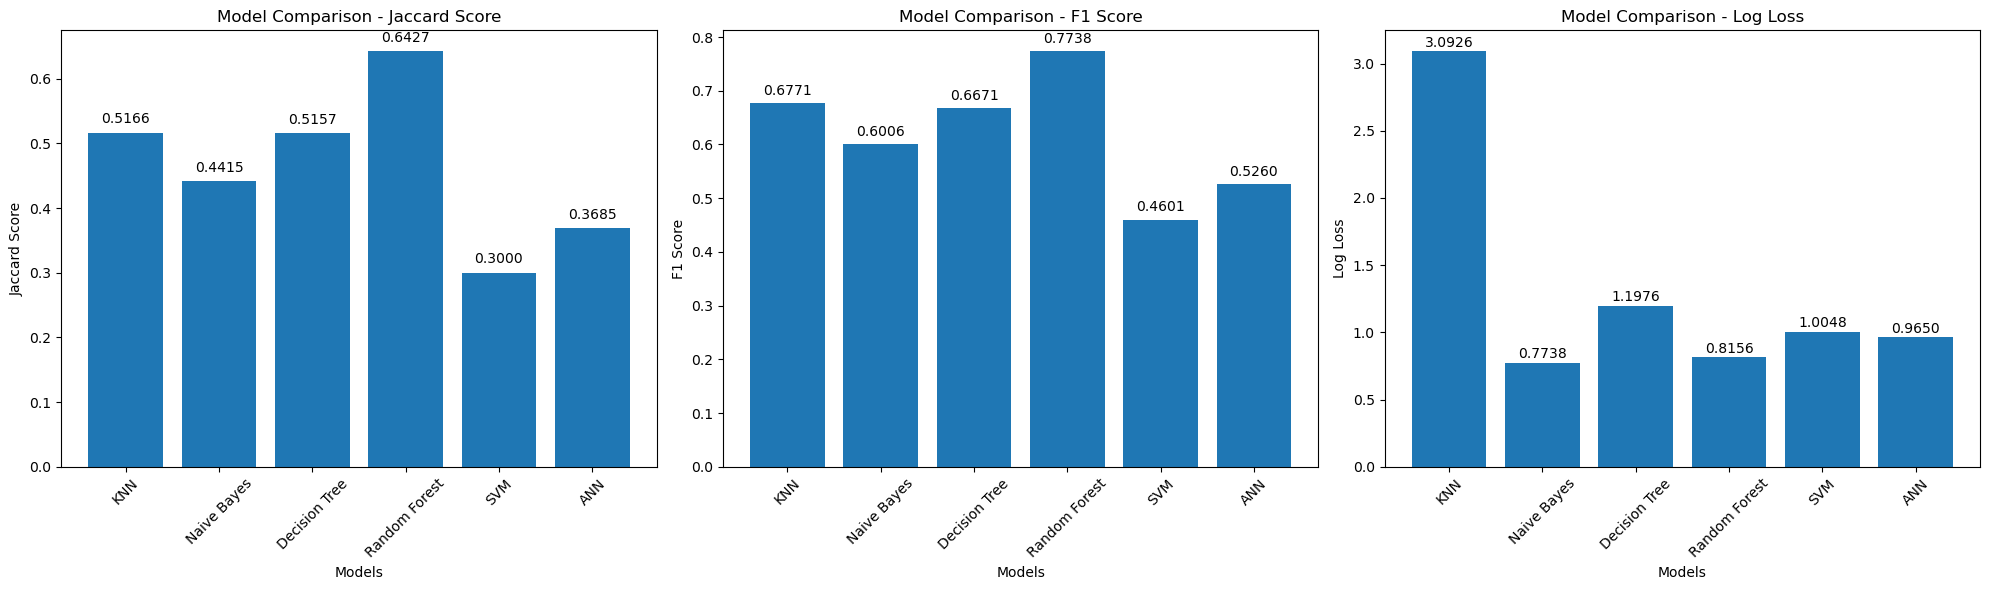

In [ ]:
# Extract model names
models = list(model_evaluations.keys())

# Extract metrics
jaccard_scores = [model_evaluations[m]['Jaccard'] for m in models]
f1_scores = [model_evaluations[m]['F1-score'] for m in models]
logloss_scores = [model_evaluations[m]['LogLoss'] for m in models]

# Create a figure with 3 subplots side-by-side
plt.figure(figsize=(20,6))

# Jaccard Plot
plt.subplot(1, 3, 1)
bars_jaccard = plt.bar(models, jaccard_scores)
plt.title("Model Comparison - Jaccard Score")
plt.xlabel("Models")
plt.ylabel("Jaccard Score")
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars_jaccard:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}",
             ha='center', va='bottom')

# F1-score Plot
plt.subplot(1, 3, 2)
bars_f1 = plt.bar(models, f1_scores)
plt.title("Model Comparison - F1 Score")
plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars_f1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}",
             ha='center', va='bottom')

# LogLoss Plot
plt.subplot(1, 3, 3)
bars_logloss = plt.bar(models, logloss_scores)
plt.title("Model Comparison - Log Loss")
plt.xlabel("Models")
plt.ylabel("Log Loss")
plt.xticks(rotation=45)

# Add values on top of bars
for bar in bars_logloss:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}",
             ha='center', va='bottom')

# Display all three plots
plt.tight_layout()
plt.show()


In [ ]:
# Function to determine the best model based on a given metric
def find_best_model(metric):
    # For LogLoss: LOWER is better → start with a large number
    if metric == 'LogLoss':
        best_score = float('inf')
    else:
        # For Jaccard & F1: HIGHER is better
        best_score = -1

    best_model = None

    for model, scores in model_evaluations.items():
        if metric in scores:
            value = scores[metric]

            # Skip "N/A" values in LogLoss
            if isinstance(value, str):
                continue

            # Logic depending on metric
            if metric == 'LogLoss':
                # Lower is better
                if value < best_score:
                    best_score = value
                    best_model = model
            else:
                # Higher is better
                if value > best_score:
                    best_score = value
                    best_model = model

    return best_model, best_score


# Get the best model for each metric
best_jaccard_model, best_jaccard_score = find_best_model('Jaccard')
best_f1_model, best_f1_score = find_best_model('F1-score')
best_logloss_model, best_logloss_score = find_best_model('LogLoss')

# Print Results
print(f"Best model based on Jaccard index: {best_jaccard_model} with a score of {best_jaccard_score:.4f}")
print(f"Best model based on F1-score: {best_f1_model} with a score of {best_f1_score:.4f}")

# LogLoss may be None if all values were N/A
if best_logloss_model is not None:
    print(f"Best model based on LogLoss: {best_logloss_model} with a score of {best_logloss_score:.4f}")
else:
    print("No valid LogLoss values for comparison.")


Best model based on Jaccard index: Random Forest with a score of 0.6427
Best model based on F1-score: Random Forest with a score of 0.7738
Best model based on LogLoss: Naive Bayes with a score of 0.7738


# Conclusion

In this project, the whole patient health data was used, which is preprocessed and cleaned throughout, and six classifiers were trained (KNN, Naive Bayes, Decision Tree, Random Forest, SVM, and ANN) to predict the risk states of individuals. The models are evaluated on a variety of metrics including Accuracy, Precision, Recall, F1-Score, Jaccard index and LogLoss, enabling an all rounded assessment of the model performance.

Based on this evaluation, Random Forest is the best model in terms of Jaccard index (0.6427) and F1-score (0.7738), and it can well be utilized to identify High-risk, Mid-risk, and Low-risk individuals based on health-related characteristics, e.g. Age, Systolic BP, Diastolic BP, Blood Sugar, Body Temperature, and Heart Rate. But, Naive Bayes is the best in LogLoss (0.7738) which means it is more sure of its probability estimates for class membership and this is really useful when probabilistic decisions are taken especially in healthcare.

The classification outcome can then be used to gain useful information about patient risk level which can be helpful to intervene in advance and do preventive health care. Multiple metric evaluations can guarantee a more reliable and robust model selection than utilizing a single performance measurement. In summary, this research signifies that machine learning can be properly utilized for health risk prediction to promote smart data-driven decisions in healthcare. In the future, work may concentrate on expanding the dataset by incorporating more features/models and enhancing prediction performance using more powerful techniques.